# Experiment 006 figures

**Every cell is self-contained.** Each one carries its own palette, rcParams and
plotting code, so any parameter can be changed in place without touching
`ska_hi_plots.py`. Run the setup cell once, then whichever figure cells you want.

The cost of that is duplication: `ska_hi_plots.py` still holds the canonical
copy used to build `ANALYSIS_LOG.pdf`, and the two will drift once you start
editing here. When a change is worth keeping, port it back to the module.

Nothing below re-solves — it reads three cached `.npz` files and takes seconds.
The heavy steps, only if those are missing:

| what | script | cost |
|---|---|---|
| TODs + operators | `ska_hi_experiment.py` | hours |
| solves, T(k) | `run_hi_experiment.py` | ~25 min |
| floor/noise ablation | `ska_hi_ablation.py` | ~5 min |
| rank + eigenvectors | `ska_hi_rank.py` | ~5 min |

Run under `gibbs_venv_312`.

## Setup — imports and cached data

In [ ]:
import os, sys
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import Image, display

import ska_hi_analysis as A          # only for pca_clean / channel_operators

RESDIR, FIGDIR = 'results', 'figures'
os.makedirs(FIGDIR, exist_ok=True)

FMT = 'pdf'            # 'pdf' for vector output
DRAW_TITLES = False     # False -> no headline/subtitle, for LaTeX captions

EXP = np.load(os.path.join(RESDIR, 'hi_experiment_f350_400_nc32_ns64.npz'))
_a = os.path.join(RESDIR, 'hi_ablation_f350_400_nc32_ns64.npz')
_r = os.path.join(RESDIR, 'hi_rank_f350_400_nc32_ns64.npz')
_f1 = os.path.join(RESDIR, 'hi_1f_scan_f350_400_nc32_ns64.npz')
_f2 = os.path.join(RESDIR, 'hi_1f_cutoff_f350_400_nc32_ns64.npz')
ABL = np.load(_a) if os.path.exists(_a) else None
RK  = np.load(_r) if os.path.exists(_r) else None
_md = os.path.join(RESDIR, 'hi_modes_f350_400_nc32_ns64.npz')
MODES = np.load(_md) if os.path.exists(_md) else None
SCAN = np.load(_f1) if os.path.exists(_f1) else None
CUT  = np.load(_f2) if os.path.exists(_f2) else None

print('experiment :', 'ok')
print('ablation   :', 'ok' if ABL is not None else 'MISSING -- run ska_hi_ablation.py')
print('rank       :', 'ok' if RK is not None else 'MISSING -- run ska_hi_rank.py')
print('modes      :', 'ok' if MODES is not None else 'MISSING -- run ska_hi_modes.py')
print('1/f knee   :', 'ok' if SCAN is not None else 'MISSING -- ska_hi_1f_scan.py')
print('1/f cutoff :', 'ok' if CUT is not None else 'MISSING -- ska_hi_1f_scan.py --mode cutoff')

experiment : ok
ablation   : ok
rank       : ok
modes      : ok
1/f knee   : ok
1/f cutoff : ok


## `hi_transfer_function`

T(k_par), drift vs raster, one panel per mode count. The cross-linking result.

figures/hi_transfer_function.pdf


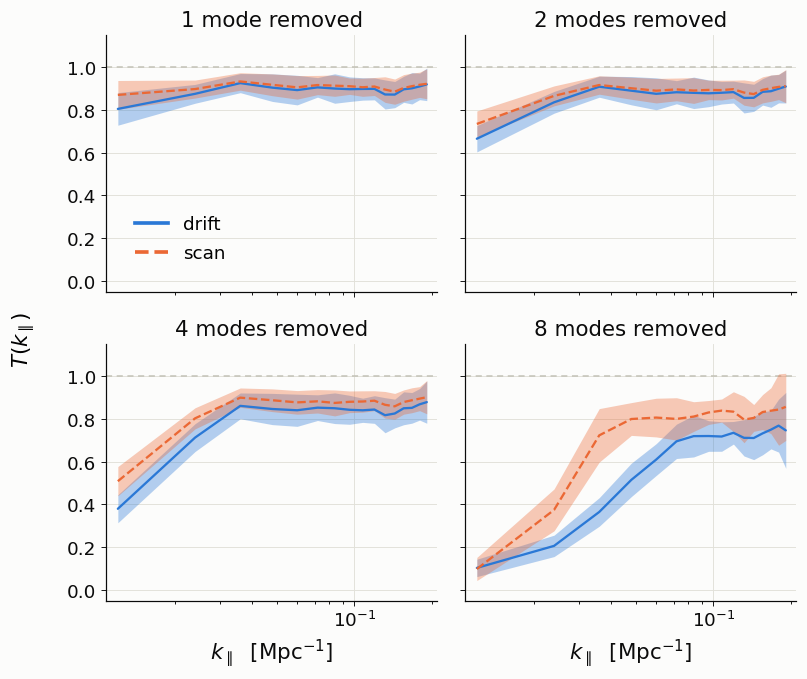

In [19]:
# ==== hi_transfer_function ==========================================
exp = EXP
var = 'cr_'   # 'cr_' common-res | 'int_' interior | '' as-run
# Which mode counts to show. Any subset of exp['nmodes_grid'] = 1,2,3,4,6,8,10.
# The grid is always 2 rows; columns follow from how many panels you ask for.
MODES_SHOWN = [1, 2, 4, 8]
NROWS = 2
# ---- palette + style (edit freely; this cell owns all of it) --------------
DRIFT, RASTER, THIRD = "#2a78d6", "#eb6834", "#1baf7a"
SURFACE = "#fcfcfb"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"
DPI_OUT = 200

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.size": 14, "axes.labelsize": 14, "axes.titlesize": 14,
    "axes.edgecolor": INK, "axes.labelcolor": INK,
    "xtick.color": INK, "ytick.color": INK,
    "xtick.labelsize": 12, "ytick.labelsize": 12,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2.0, "figure.dpi": 110,
})

STRAT = {"drift":  dict(color=DRIFT,  label="drift",linestyle='-',linewidth=1.5),
         "raster": dict(color=RASTER, label="scan",linestyle='--',linewidth=1.5)}

def _tidy(ax):
    ax.set_axisbelow(True)
    ax.tick_params(length=3, width=0.6)
    return ax

available = [int(n) for n in exp["nmodes_grid"]]
nmodes = [n for n in MODES_SHOWN if n in available]
missing = [n for n in MODES_SHOWN if n not in available]
if missing:
    print(f"not in nmodes_grid, skipped: {missing}")
k = exp[f"drift_{var}k"]
ncols = int(np.ceil(len(nmodes) / NROWS))
fig, axes = plt.subplots(NROWS, ncols, figsize=(3.35 * ncols + 0.8, 6.4),
                         sharex=True, sharey=True, squeeze=False)
flat = axes.ravel()
# An odd panel count leaves one cell free; it takes the legend, as the 2x4
# layout did. An even count has none, so the legend goes figure-level.
spare = flat[len(nmodes):]

for ax, nm in zip(flat, nmodes):
    _tidy(ax)
    ax.axhline(1.0, color=BASELINE, lw=1.0, ls=(0, (4, 3)), zorder=1)
    for s, style in STRAT.items():
        t = exp[f"{s}_{var}tf_{nm}"]
        e = exp[f"{s}_{var}tf_scatter_{nm}"]
        ax.fill_between(k, t - e, t + e, color=style["color"], alpha=0.35,
                        lw=0, zorder=2)
        ax.plot(k, t, color=style["color"], zorder=3, linestyle=style["linestyle"], linewidth=style["linewidth"],
                solid_capstyle="round")
    ax.set_xscale("log")
    ax.set_title(f"{nm} mode{'s' if nm > 1 else ''} removed",
                 color=INK, pad=6)
    ax.set_ylim(-0.05, 1.15)
    ax.set_xlim(k.min() * 0.9, k.max() * 1.1)

# The x axis belongs to the lowest *occupied* cell in each column -- with a
# spare cell that is not always the bottom row.
for col in range(ncols):
    for row in range(NROWS - 1, -1, -1):
        ax = axes[row, col]
        if ax in flat[:len(nmodes)].tolist():
            ax.tick_params(labelbottom=True)
            ax.set_xlabel("$k_\\parallel$  [Mpc$^{-1}$]")
            break

# Legend inside the first panel -- the curves are far apart there, and the
# lower half of that panel is empty at every mode count. The dashed T=1 line
# is left out of the key; it is stated in the caption instead.
a0 = flat[0]
a0.legend(handles=[Line2D([], [], color=v["color"], lw=2.4, label=v["label"], linestyle=v["linestyle"], linewidth=v["linewidth"])
                   for v in STRAT.values()],
          loc="lower left", handlelength=1.8, labelspacing=0.6,
          borderpad=0.8, borderaxespad=0.8, fontsize=12)

if len(spare):
    # Spare cell keeps the reading instruction.
    sp = spare[0]
    sp.set_axis_off()
    sp.text(-0.02, 0.95,
            "Band = $\\pm1\\sigma$ over 20\nindependent HI mocks.\n\n"
            "Loss concentrates at low\n$k_\\parallel$: those modes are the\n"
            "smoothest along the line of\nsight, so PCA mistakes them\n"
            "for foreground.",
            transform=sp.transAxes, va="top", color=INK2, fontsize=8.6,
            linespacing=1.5)

# One shared y label — per-axes labels on a shared axis collide.
fig.supylabel("$T(k_\\parallel)$",
              color='k', fontsize=14)

if DRAW_TITLES:
    fig.suptitle("Cross-linking preserves HI through foreground cleaning at every scale",
                 color=INK, fontsize=13, fontweight="semibold",
                 x=0.055, ha="left", y=0.985)
    fig.text(0.055, 0.938,
             "350$-$400 MHz, 32 channels, nside 64. Channels reconvolved to a "
             "common 3.99$\\degree$ beam, 119 interior pixels. $T$ is each "
             "strategy's ratio against its own injected response, so it is "
             "depth-independent.",
             color=INK2, fontsize=9.4, ha="left")
# Nothing sits above the panels any more, so no header needs reserving.
fig.tight_layout(rect=(0, 0, 1, 0.98))
out = os.path.join(FIGDIR, "hi_transfer_function." + FMT)
fig.savefig(out, bbox_inches="tight", dpi=DPI_OUT)
plt.tight_layout()
print(out)

display(Image(out)) if FMT == "png" else None

## `hi_residual_vs_modes`

Post-clean residual against the HI, as run and after reconvolution.

In [ ]:
# ==== hi_residual_vs_modes ==========================================
exp = EXP
# ---- palette + style (edit freely; this cell owns all of it) --------------
DRIFT, RASTER, THIRD = "#2a78d6", "#eb6834", "#1baf7a"
SURFACE = "#fcfcfb"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"
DPI_OUT = 200

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.size": 14, "axes.labelsize": 14, "axes.titlesize": 14,
    "axes.edgecolor": INK, "axes.labelcolor": INK,
    "xtick.color": INK, "ytick.color": INK,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2.0, "figure.dpi": 110,
})

STRAT = {"drift":  dict(color=DRIFT,  label="Drift (parked, no cross-linking)"),
         "raster": dict(color=RASTER, label="Raster (cross-linked, ~74$\\degree$)")}

def _tidy(ax):
    ax.set_axisbelow(True)
    ax.tick_params(length=3, width=0.6)
    return ax

nmodes = [int(n) for n in exp["nmodes_grid"]]
fig, ax = plt.subplots(figsize=(8.6, 5.6))
_tidy(ax)

VAR = [("int_", (0, (5, 2)), "none", "as run"),
       ("cr_", "-", SURFACE, "common resolution")]
for s, style in STRAT.items():
    for var, ls, mfc, _lab in VAR:
        med = [np.median(np.sqrt(exp[f"{s}_{var}p_clean_auto_{nm}"]
                                 / exp[f"{s}_{var}p_mapmade"]))
               for nm in nmodes]
        ax.plot(nmodes, med, color=style["color"], ls=ls, marker="o", ms=6,
                mfc=mfc, mec=style["color"], mew=2.0,
                alpha=1.0 if var == "cr_" else 0.55, zorder=3)
    ax.annotate(s, (nmodes[-1], med[-1]), textcoords="offset points",
                xytext=(12, 0), color=style["color"], fontsize=9.5,
                fontweight="semibold", va="center")

ax.axhline(1.0, color=INK, lw=1.4)
ax.annotate("HI level — residual would have to reach here",
            (nmodes[0], 1.0), textcoords="offset points", xytext=(2, 7),
            color=INK, fontsize=8.8)
ax.set_yscale("log")
ax.set_xlabel("PCA modes removed")
ax.set_ylabel("post-clean residual / HI   (amplitude)")
ax.set_xticks(nmodes); ax.set_xticklabels([str(n) for n in nmodes])
ax.set_xlim(0.4, nmodes[-1] + 2.6)
ax.legend(handles=[Line2D([], [], color=MUTED, ls=ls, marker="o", ms=6,
                          mfc=(SURFACE if var == "cr_" else "none"),
                          mec=MUTED, mew=2.0, label=lab)
                   for var, ls, _m, lab in VAR],
          loc="center left", bbox_to_anchor=(0.02, 0.30),
          handlelength=2.6, labelspacing=0.8)
if DRAW_TITLES:
    ax.set_title(("Reconvolving to a common beam halves the raster's "
                 "residual, and does nothing for the drift"),
                 color=INK, fontsize=12, fontweight="semibold", loc="left",
                 pad=26)
    ax.text(0, 1.045,
            ("Both variants on the same 119 interior pixels. Even "
                   "corrected, the cross-linked raster is still "
                   "13$-$30$\\times$ above the HI."),
            transform=ax.transAxes, color=INK2, fontsize=9.2)
fig.tight_layout()
out = os.path.join(FIGDIR, "hi_residual_vs_modes." + FMT)
fig.savefig(out, bbox_inches="tight", dpi=DPI_OUT)
print(out)

display(Image(out)) if FMT == "png" else None

## `hi_ablation`

Floor vs total vs noise-only. The rings sit on the line: the noise is irrelevant.

figures/hi_ablation.pdf


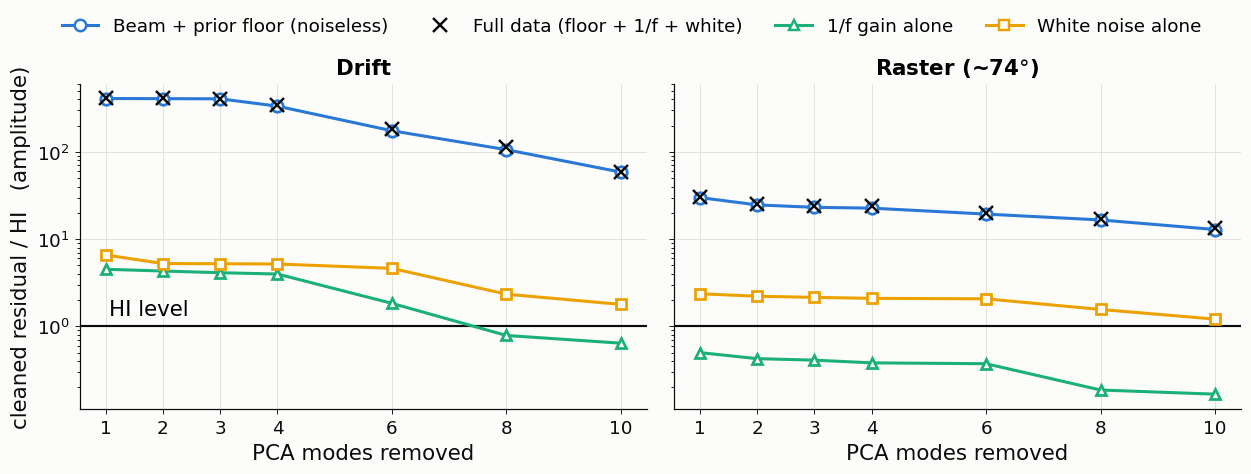

In [ ]:
# ==== hi_ablation ===================================================
abl = ABL
# Which convention to plot. 'cr_' = common resolution + interior pixels, the
# same footing as hi_residual_vs_modes; 'int_' = as run, interior pixels;
# '' = as run, full 277 px patch (the numbers published before 2026-08-26).
TAG = 'cr_'
if f'drift_{TAG}p_hi' not in abl:
    print(f"results predate the '{TAG}' variant -- rerun ska_hi_ablation.py")
    TAG = ''
# ---- palette + style (edit freely; this cell owns all of it) --------------
DRIFT, RASTER, THIRD = "#2a78d6", "#eb6834", "#1baf7a"
SURFACE = "#fcfcfb"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"
DPI_OUT = 200

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.size": 14, "axes.labelsize": 14, "axes.titlesize": 14,
    "axes.edgecolor": INK, "axes.labelcolor": INK,
    "xtick.color": INK, "ytick.color": INK,
    "xtick.labelsize": 12, "ytick.labelsize": 12,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2.0, "figure.dpi": 110,
})

STRAT = {"drift":  dict(color='k',  label="Drift"),
         "raster": dict(color='k', label="Raster (~74$\\degree$)")}

def _tidy(ax):
    ax.set_axisbelow(True)
    ax.tick_params(length=3, width=0.6)
    return ax

nmodes = [int(n) for n in abl["nmodes_grid"]]
# key, colour, label, linestyle, marker, markersize -- one marker per line so
# the arms stay separable in greyscale and for CVD readers.
#
# FOURTH is slot 4 of the validated categorical palette. Slot 2 (orange) is
# reserved for "raster" across this figure set, so it would clash used as a
# noise term inside a per-strategy panel. Validated on all pairs for
# blue/aqua/yellow: CVD dE 9.1 (target 8), normal-vision dE 22.9 (floor 15);
# yellow's surface contrast is 2.11, a WARN, which is why every line is
# legended AND carries its own marker rather than resting on hue.
FOURTH = "#eda100"
arms = [("floor",     DRIFT,  "Beam + prior floor (noiseless)",  "-",    ".", 15),
        ("total",     INK,    "Full data (floor + 1/f + white)", "none", "x",  9),
        ("gainonly",  THIRD,  "1/f gain",                  "-",    "^",  7),
        ("whiteonly", FOURTH, "White noise",               "-",    "s",  6)]
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.9), sharey=True)

for ax, s in zip(axes, ("drift", "raster")):
    _tidy(ax)
    p_hi = abl[f"{s}_{TAG}p_hi"]
    for arm, colour, label, ls, mk, ms in arms:
        med = [np.median(np.sqrt(abl[f"{s}_{TAG}{arm}_{nm}"] / p_hi))
               for nm in nmodes]
        if arm == "total":
            # Markers only, on top of `floor`: the point is that they coincide.
            ax.plot(nmodes, med, ls="none", marker=mk, ms=ms,
                    mfc="none", mec=colour, mew=1.6, zorder=4)
        else:
            ax.plot(nmodes, med, color=colour, ls=ls, marker=mk, ms=ms,
                    mfc=SURFACE, mew=1.8, zorder=3)
    ax.axhline(1.0, color=INK, lw=1.4, zorder=2)
    ax.set_yscale("log")
    ax.set_xticks(nmodes); ax.set_xticklabels([str(n) for n in nmodes])
    ax.set_xlabel("PCA modes removed")
    ax.set_title(STRAT[s]["label"], color=STRAT[s]["color"], pad=6,
                 fontweight="semibold")
axes[0].set_ylabel("cleaned residual / HI   (amplitude)")
axes[0].annotate("HI level", (nmodes[0], 1.0), textcoords="offset points",
                 xytext=(2, 7), color='k', fontsize=14)

# Figure-level and horizontal: inside either panel it collides with the
# noise curve or the HI-level line.
fig.legend(handles=[Line2D([], [], color=c, ls=(ls if ls != "none" else "none"),
                           marker=mk, ms=ms,
                           mfc=("none" if a == "total" else SURFACE),
                           mec=c, mew=1.6, lw=(0 if ls == "none" else 2),
                           label=lab)
                    for a, c, lab, ls, mk, ms in arms],
           loc="upper left", bbox_to_anchor=(0.045, 0.90), ncols=4,
           handlelength=2.0, columnspacing=1.8,fontsize=12)

if DRAW_TITLES:
    fig.suptitle("The blocker is the floor, and 1/f is the smallest term in it",
                 color=INK, fontsize=13, fontweight="semibold",
                 x=0.045, ha="left", y=1.03)
    fig.text(0.045, 0.965,
             "Noiseless and full data track each other to a few per cent. "
             "Split apart, 1/f sits below the white noise, which is itself far "
             "below the floor — so neither is what limits HI recovery.",
             color=INK2, fontsize=9.4, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.84))
out = os.path.join(FIGDIR, "hi_ablation." + FMT)
fig.savefig(out, bbox_inches="tight", dpi=DPI_OUT)
print(out)

display(Image(out)) if FMT == "png" else None

## `hi_frequency_structure`

Radial power surviving the map-maker, and the frequency-structure split.

In [ ]:
# ==== hi_frequency_structure ========================================
exp = EXP
# ---- palette + style (edit freely; this cell owns all of it) --------------
DRIFT, RASTER, THIRD = "#2a78d6", "#eb6834", "#1baf7a"
SURFACE = "#fcfcfb"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"
DPI_OUT = 200

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.size": 9.5, "axes.labelsize": 10, "axes.titlesize": 10.5,
    "axes.edgecolor": INK, "axes.labelcolor": INK,
    "xtick.color": INK, "ytick.color": INK,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2.0, "figure.dpi": 110,
})

STRAT = {"drift":  dict(color=DRIFT,  label="Drift (parked, no cross-linking)"),
         "raster": dict(color=RASTER, label="Raster (cross-linked, ~74$\\degree$)")}

def _tidy(ax):
    ax.set_axisbelow(True)
    ax.tick_params(length=3, width=0.6)
    return ax

freqs = exp["freqs"]
k = exp["drift_k"]
fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.0),
                         gridspec_kw=dict(width_ratios=[1, 1.15]))

# (a) radial power retained by the map-maker
ax = _tidy(axes[0])
for s, style in STRAT.items():
    ratio = exp[f"{s}_p_mapmade"] / exp[f"{s}_p_true"]
    ax.plot(k, ratio, color=style["color"], marker="o", ms=4,
            mfc=SURFACE, mew=1.4, label=s)
    # Label at the left end, where the two curves are furthest apart and
    # there is clear space; at the right end they collide with the markers.
    ax.annotate(s, (k[0], ratio[0]), textcoords="offset points",
                xytext=(6, 10), color=style["color"], fontsize=9.5,
                fontweight="semibold", ha="left")
ax.set_xscale("log")
ax.set_ylim(0, 0.42)
ax.set_xlabel("$k_\\parallel$  [Mpc$^{-1}$]")
ax.set_ylabel("$P_\\mathrm{map\\,made}\\,/\\,P_\\mathrm{true}$")
ax.set_title("Radial HI power surviving the map-maker", color=INK, pad=6)

# (b) the frequency-structure split, which is the actual mechanism.
# A single line of sight was tried here and did not show it -- the traces
# are too noisy to read "flat in frequency" off by eye. The two ratios
# state it directly, and share an axis because both are map-made/true.
ax = _tidy(axes[1])
metrics, groups = [], ["frequency-varying\npart retained",
                       "frequency-coherent\npart (the mean)"]
for s in STRAT:
    t, m = exp[f"{s}_hi_true"], exp[f"{s}_hi_mapmade"]
    varying = ((m - m.mean(axis=0)).std() / (t - t.mean(axis=0)).std())
    coherent = m.mean(axis=0).std() / t.mean(axis=0).std()
    metrics.append((varying, coherent))
x = np.arange(2)
w = 0.34
for i, (s, style) in enumerate(STRAT.items()):
    off = (i - 0.5) * (w + 0.02)
    bars = ax.bar(x + off, metrics[i], width=w, color=style["color"],
                  edgecolor=SURFACE, linewidth=2.0, zorder=3,
                  label=style["label"])
    for b, v in zip(bars, metrics[i]):
        ax.annotate(f"{v:.2f}$\\times$",
                    (b.get_x() + b.get_width() / 2, v),
                    textcoords="offset points", xytext=(0, 4),
                    ha="center", color=INK, fontsize=9.5,
                    fontweight="semibold")
ax.axhline(1.0, color=INK, lw=1.4, zorder=4)
# Left of the bars: at the right it collides with the raster bar's label.
ax.annotate("1.0 — faithful", (-0.47, 1.0), textcoords="offset points",
            xytext=(0, 6), color=INK, fontsize=8.8, ha="left")
ax.set_xticks(x); ax.set_xticklabels(groups, color=INK2)
ax.set_ylabel("map-made / true   (rms ratio)")
ax.set_ylim(0, 3.7)
ax.set_xlim(-0.55, 1.55)   # explicit, else the reference-line label clips
ax.set_title("The drift suppresses structure and inflates the mean",
             color=INK, pad=6)
ax.grid(axis="x", visible=False)
ax.legend(loc="upper left", bbox_to_anchor=(0.015, 0.99))

if DRAW_TITLES:
    fig.suptitle("Why the drift fails: it turns HI into something that looks like foreground",
                 color=INK, fontsize=13, fontweight="semibold",
                 x=0.045, ha="left", y=1.01)
    fig.text(0.045, 0.945,
             "The drift keeps only 38% of the frequency-varying HI while "
             "amplifying the frequency-coherent part 3.14$\\times$ "
             "(raster: 0.53 and 1.11$\\times$). With ~17 measured modes it "
             "projects HI onto a nearly frequency-constant subspace.",
             color=INK2, fontsize=9.4, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.90))
out = os.path.join(FIGDIR, "hi_frequency_structure." + FMT)
fig.savefig(out, bbox_inches="tight", dpi=DPI_OUT)
print(out)

display(Image(out)) if FMT == "png" else None

## `hi_patch_maps`

The GDSM field and the nested drift / raster / interior footprints.

figures/hi_patch_maps.pdf


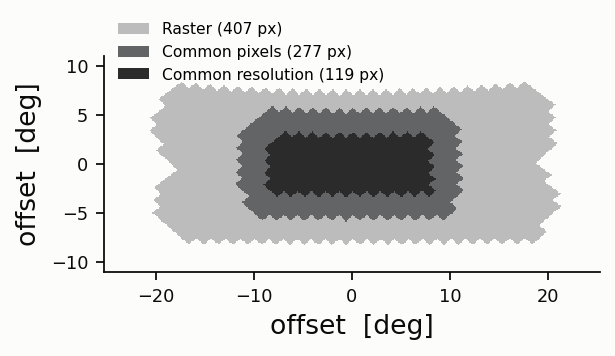

In [44]:
# ==== hi_patch_maps =================================================
exp = EXP
nside, channel = 64, None
# ---- palette + style (edit freely; this cell owns all of it) --------------
DRIFT, RASTER, THIRD = "#636465", "#bcbcbc", "#1baf7a"
SURFACE = "#fcfcfb"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"
DPI_OUT = 200

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.size": 14, "axes.labelsize": 14, "axes.titlesize": 14,
    "axes.edgecolor": INK, "axes.labelcolor": INK,
    "xtick.color": INK, "ytick.color": INK,
    "xtick.labelsize": 12, "ytick.labelsize": 12,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.fontsize": 12,
    "lines.linewidth": 2.0, "figure.dpi": 160,
})

def _cmaps():
    from matplotlib.colors import LinearSegmentedColormap
    div = LinearSegmentedColormap.from_list(
        "blue_grey_red", ["#184f95", "#2a78d6", "#f0efec", "#e34948", "#a02b2b"])
    seq = LinearSegmentedColormap.from_list(
        "blues", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf",
                  "#184f95", "#0d366b"])
    for c in (div, seq):
        c.set_bad(SURFACE)          # unobserved sky reads as page, not as data
    return div, seq


def _project(values, pix, nside, reso, xsize, rot):
    full = np.full(hp.nside2npix(nside), hp.UNSEEN)
    full[np.asarray(pix)] = values
    return hp.gnomview(full, rot=rot, reso=reso, xsize=xsize, no_plot=True,
                       return_projected_map=True)


def _mapshow(ax, img, cmap, vmin, vmax, title, extent):
    im = ax.imshow(img, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax,
                   extent=extent, interpolation="nearest")
    #ax.set_title(title, color=INK, fontsize=10, pad=5)
    ax.set_xlabel("offset  [deg]", fontsize=12)
    ax.grid(False)
    ax.tick_params(labelsize=8)
    return im

import healpy as hp
from ska_common import gdsm_equatorial_sky_model

div, seq = _cmaps()
common = exp["common"]
interior = exp["interior"]
ops = {s: A.channel_operators(s, verbose=False)[0]
       for s in ("drift", "raster")}
rot = (158.30, 9.375)
reso, xsize = 8.0, 380
half = reso * xsize / 60.0 / 2.0
extent = (-half, half, -half, half)

# The GDSM panel that used to sit at left is dropped: the field is described
# in the text, and the footprints are what this figure is for. `seq` and
# `gdsm_equatorial_sky_model` are left imported so it can be put back.
fig, ax = plt.subplots(1, 1, figsize=(4, 4), layout=None)
axes = [ax]
allpix = np.union1d(np.asarray(ops["drift"].pixel_indices),
                    np.asarray(ops["raster"].pixel_indices))

# Coverage. Categorical, so it uses the categorical slots, not a ramp.
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
code = np.zeros(hp.nside2npix(nside))
code[np.asarray(ops["raster"].pixel_indices)] = 1
code[common] = 2
code[np.asarray(common)[interior]] = 3
img = _project(code[allpix], allpix, nside, reso, xsize, rot)
cmap = ListedColormap(["#d8d7d0", RASTER, DRIFT, "#2B2B2B"])
ax.imshow(img, origin="lower", cmap=cmap,
               norm=BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], 4),
               extent=extent, interpolation="nearest")
#ax.set_title("What each strategy solves", color=INK, fontsize=10, pad=5)
ax.set_xlabel("offset  [deg]", fontsize=12)
ax.grid(False); ax.tick_params(labelsize=8)
n_rast_only = len(ops["raster"].pixel_indices) - len(common)
ax.legend(handles=[
    Patch(facecolor=RASTER, label=f"Raster ({n_rast_only} px)"),
    Patch(facecolor=DRIFT, label=f"Common pixels ({len(common)} px)"),
    Patch(facecolor="#2B2B2B",
          label=f"Common resolution ({interior.sum()} px)")],
    loc="upper left", bbox_to_anchor=(0.0, 1.225), fontsize=7, ncol=1)
ax.set_ylabel("offset  [deg]", fontsize=12)
ax.set_ylim(-11, 11)            # a wide strip; square axes would be empty page

if DRAW_TITLES:
    fig.suptitle("The field and the two footprints",
                 color=INK, fontsize=13, fontweight="semibold",
                 x=0.01, ha="left", y=1.13)
    fig.text(0.01, 1.04,
             "Gnomonic projection about RA 158.3$\\degree$, Dec +9.4$\\degree$. The drift's "
             "patch is a stack of three constant-Dec strips; the raster's azimuth "
             "throw widens it 2.2$\\times$ and wholly contains it "
             f"({len(ops['raster'].pixel_indices)} px against "
             f"{len(ops['drift'].pixel_indices)}).",
             color=INK2, fontsize=9.4, ha="left")
out = os.path.join(FIGDIR, "hi_patch_maps." + FMT)
fig.savefig(out, bbox_inches="tight", dpi=DPI_OUT)
print(out)

display(Image(out)) if FMT == "png" else None

## `hi_maps`

HI in the map domain. The fourth panel is on a 50x wider colour scale.

/home/geoff/limTOD/examples/SKA/ska_hi_analysis.py:124: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  out[i] = hp.smoothing(full, fwhm=np.radians(kernel), verbose=False)[pix]


figures/hi_maps.pdf


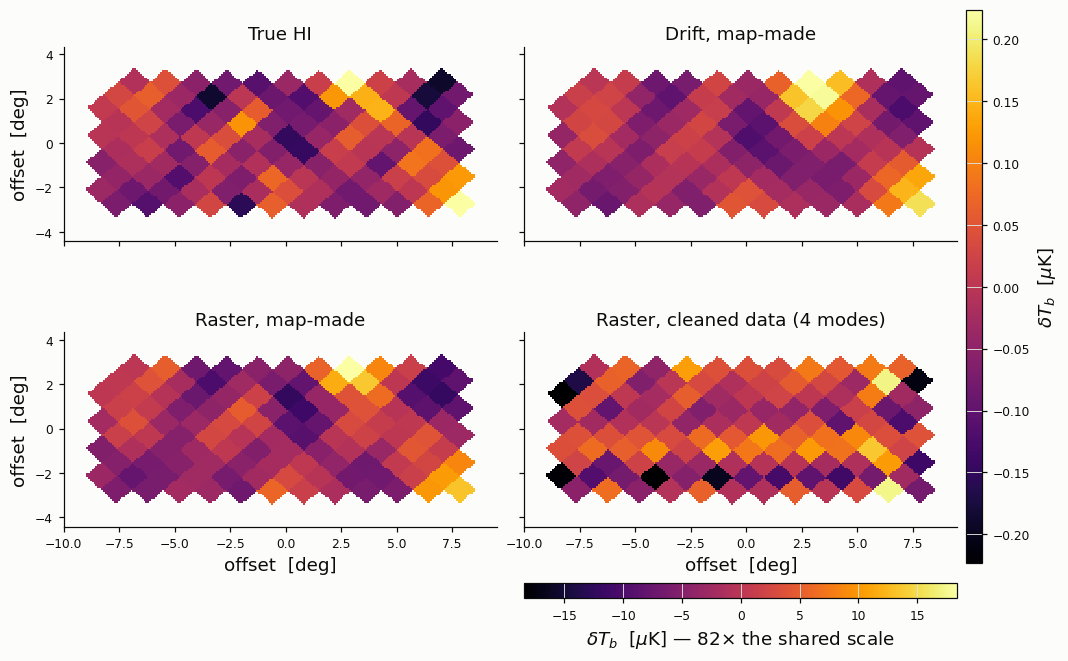

In [3]:
# ==== hi_maps =======================================================
exp = EXP
nside, nmodes = 64, 4
# 'cr_'   -> common resolution, 119 interior px: the footing every quantitative
#            figure uses. 'as_run' -> full 277 px at native per-channel beam.
VARIANT = 'cr_'
# ---- palette + style (edit freely; this cell owns all of it) --------------
DRIFT, RASTER, THIRD = "#2a78d6", "#eb6834", "#1baf7a"
SURFACE = "#fcfcfb"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"
DPI_OUT = 200

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.size": 14, "axes.labelsize": 14, "axes.titlesize": 14,
    "axes.edgecolor": INK, "axes.labelcolor": INK,
    "xtick.color": INK, "ytick.color": INK,
    "xtick.labelsize": 14, "ytick.labelsize": 1214,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.fontsize": 1142,
    "lines.linewidth": 2.0, "figure.dpi": 110,
})

def _cmaps():
    from matplotlib.colors import LinearSegmentedColormap
    div = LinearSegmentedColormap.from_list(
        "blue_grey_red", ["#184f95", "#2a78d6", "#f0efec", "#e34948", "#a02b2b"])
    seq = LinearSegmentedColormap.from_list(
        "blues", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf",
                  "#184f95", "#0d366b"])
    for c in (div, seq):
        c.set_bad(SURFACE)          # unobserved sky reads as page, not as data
    return div, seq


def _project(values, pix, nside, reso, xsize, rot):
    full = np.full(hp.nside2npix(nside), hp.UNSEEN)
    full[np.asarray(pix)] = values
    return hp.gnomview(full, rot=rot, reso=reso, xsize=xsize, no_plot=True,
                       return_projected_map=True)


def _data_window(img, extent, pad=1.0):
    """(xlim, ylim) enclosing the observed pixels, with a small margin."""
    good = np.isfinite(img) & (img != hp.UNSEEN)
    rows = np.flatnonzero(good.any(axis=1)); cols = np.flatnonzero(good.any(axis=0))
    if not len(rows) or not len(cols):
        return (extent[0], extent[1]), (extent[2], extent[3])
    x0, x1, y0, y1 = extent
    dx, dy = (x1 - x0) / img.shape[1], (y1 - y0) / img.shape[0]
    return ((x0 + dx * cols[0] - pad, x0 + dx * (cols[-1] + 1) + pad),
            (y0 + dy * rows[0] - pad, y0 + dy * (rows[-1] + 1) + pad))


def _mapshow(ax, img, cmap, vmin, vmax, title, extent):
    im = ax.imshow(img, origin="lower", cmap='inferno', vmin=vmin, vmax=vmax,
                   extent=extent, interpolation="nearest")
    ax.set_title(title, color=INK, fontsize=12, pad=5)
    ax.set_xlabel("offset  [deg]", fontsize=12)
    ax.grid(False)
    ax.tick_params(labelsize=8)
    return im

div, _ = _cmaps()
common = np.asarray(exp["common"])
freqs = exp["freqs"]
ch = len(freqs) // 2
rot = (158.30, 9.375)
reso, xsize = 5.0, 330
half = reso * xsize / 60.0 / 2.0
extent = (-half, half, -half, half)

def demean(c):
    return c - c.mean(axis=0, keepdims=True)

if VARIANT in ('cr_', 'cr'):
    interior = np.asarray(exp["interior"], bool)
    pix = common[interior]
    def prep(cube):
        return A.common_resolution(np.asarray(cube), freqs, common,
                                   nside)[:, interior]
else:
    pix = common
    def prep(cube):
        return np.asarray(cube)

true = demean(prep(exp["drift_hi_true"]))[ch] * 1e3          # uK
dmap = demean(prep(exp["drift_hi_mapmade"]))[ch] * 1e3
rmap = demean(prep(exp["raster_hi_mapmade"]))[ch] * 1e3
# Reconvolve first, then clean -- the order run_hi_experiment.py uses.
clean = demean(A.pca_clean(prep(exp["raster_data_cube"]), nmodes))[ch] * 1e3

v = float(np.nanpercentile(np.abs(true), 99))
v_clean = float(np.nanpercentile(np.abs(clean), 99))
# Explicit gridspec rather than plt.subplots: a colorbar attached to one panel
# steals space from that panel alone, leaving the 2x2 visibly unequal.
fig = plt.figure(figsize=(9.6, 5.9), layout="constrained")
gs = fig.add_gridspec(3, 3, height_ratios=[1, 1, 0.055],
                      width_ratios=[1, 1, 0.035])
flat = [fig.add_subplot(gs[r, c]) for r in (0, 1) for c in (0, 1)]
cax_shared = fig.add_subplot(gs[0:2, 2])
cax_clean = fig.add_subplot(gs[2, 1])
panels = [(true, "True HI", v), (dmap, "Drift, map-made", v),
          (rmap, "Raster, map-made", v),
          (clean, f"Raster, cleaned data ({nmodes} modes)", v_clean)]
ims = []
win = None
for ax, (vals, title, vv) in zip(flat, panels):
    img = _project(vals, pix, nside, reso, xsize, rot)
    ims.append(_mapshow(ax, img, div, -vv, vv, title, extent))
    # Size the window to the patch: the interior is much shorter than the full
    # common patch, and dead paper around it doubles in a 2x2 grid.
    win = win or _data_window(img, extent)
    ax.set_xlim(*win[0]); ax.set_ylim(*win[1])
# Axis furniture only on the outer edges of the grid.
for ax in flat[:2]:
    ax.set_xlabel("")
    ax.tick_params(labelbottom=False)      # bottom row carries the axis
for ax in (flat[1], flat[3]):
    ax.tick_params(labelleft=False)
for ax in (flat[0], flat[2]):
    ax.set_ylabel("offset  [deg]", fontsize=12)
# One bar for the three panels that share a scale, one for the outlier --
# four identical bars would imply four different scales. The odd one is
# horizontal under its own panel so the split reads before the numbers do.
cb = fig.colorbar(ims[0], cax=cax_shared)
cb.set_label("$\\delta T_b$  [$\\mu$K]", fontsize=12)
cb.ax.tick_params(labelsize=8)
cb2 = fig.colorbar(ims[3], cax=cax_clean, orientation="horizontal")
# Derived, not hardcoded: the ratio moves with `nmodes` (51x at 4 modes, 186x
# at 2, 18x at 8), and a fixed "50x" would quietly go wrong.
cb2.set_label(f"$\\delta T_b$  [$\\mu$K] — {v_clean / v:.0f}$\\times$ "
              "the shared scale", fontsize=12)
cb2.ax.tick_params(labelsize=8)

if DRAW_TITLES:
    fig.suptitle("The HI in the map domain, and why you cannot see it",
                 color=INK, fontsize=13, fontweight="semibold",
                 x=0.01, ha="left", y=1.10)
    fig.text(0.01, 1.02,
             f"Channel {ch} ({freqs[ch]:.1f} MHz), frequency mean removed. First "
             "three share a colour scale; the fourth needs its own, and that is "
             "the result — the cleaned map is residual, not signal.",
             color=INK2, fontsize=9.4, ha="left")
out = os.path.join(FIGDIR, "hi_maps." + FMT)
fig.savefig(out, bbox_inches="tight", dpi=DPI_OUT)
print(out)

display(Image(out)) if FMT == "png" else None

## `hi_rank`

Eigenspectra: is the floor compressible?

In [ ]:
# ==== hi_rank =======================================================
rank = RK
nshow = 20
# ---- palette + style (edit freely; this cell owns all of it) --------------
DRIFT, RASTER, THIRD = "#2a78d6", "#eb6834", "#1baf7a"
SURFACE = "#fcfcfb"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"
DPI_OUT = 200

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.size": 9.5, "axes.labelsize": 10, "axes.titlesize": 10.5,
    "axes.edgecolor": INK, "axes.labelcolor": INK,
    "xtick.color": INK, "ytick.color": INK,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2.0, "figure.dpi": 110,
})

def _tidy(ax):
    ax.set_axisbelow(True)
    ax.tick_params(length=3, width=0.6)
    return ax

fig, ax = plt.subplots(1, 1, figsize=(6.4, 4.8), layout="constrained")
series = [("drift_w_fg", INK, "GDSM foreground", "-"),
          ("drift_w_floor", DRIFT, "beam + prior floor, drift", "-"),
          ("raster_w_floor", RASTER, "beam + prior floor, raster", "-"),
          ("drift_w_hi", THIRD, "HI (map-made)", "-")]

_tidy(ax)
for key, colour, label, ls in series:
    w = rank[key][:nshow]
    ax.plot(np.arange(1, len(w) + 1), np.maximum(w, 1e-18), color=colour,
            ls=ls, marker="o", ms=3.5, mfc=SURFACE, mew=1.2, label=label)
ax.set_yscale("log")
ax.set_ylim(1e-18, 3)
ax.set_xlabel("eigenmode of the channel-channel covariance")
ax.set_ylabel("$\\lambda_i\\,/\\,\\lambda_1$")
ax.set_title("Eigenspectrum", color=INK, pad=6)
ax.legend(loc="center right", fontsize=8.4)  # lower left sits on the GDSM line
# The cumulative-variance panel that used to sit alongside is dropped: it
# restates this one. Its content, for the caption -- modes to reach 90/99/99.9%
# of the variance, out of 32 channels:
#     GDSM foreground   1 /  1 /  1        floor, drift   2 /  6 / 10
#     floor, raster     1 /  2 /  5        HI, drift     14 / 23 / 28
#                                          HI, raster    17 / 25 / 30
# Note the shelf at 1e-18 is numerically zero, not a measured tail: 15 of the
# foreground's 32 eigenvalues are non-positive (it is rank 1 to machine
# precision) and are clamped so the log axis can draw them.

if DRAW_TITLES:
    fig.suptitle("A different cleaning basis cannot help: the floor is already low-rank",
                 color=INK, fontsize=13, fontweight="semibold",
                 x=0.01, ha="left", y=1.10)
    fig.text(0.01, 1.02,
             "The foreground is rank 1 — one mode removes it. The floor needs 6 "
             "(drift) or 2 (raster). The HI needs 23$-$25 of 32: it is the one "
             "component that is not compressible.",
             color=INK2, fontsize=9.4, ha="left")
out = os.path.join(FIGDIR, "hi_rank." + FMT)
fig.savefig(out, bbox_inches="tight", dpi=DPI_OUT)
print(out)

display(Image(out)) if FMT == "png" else None

## `hi_eigenvectors`

The spectral shapes, and how much each one carries.

figures/hi_eigenvectors.pdf


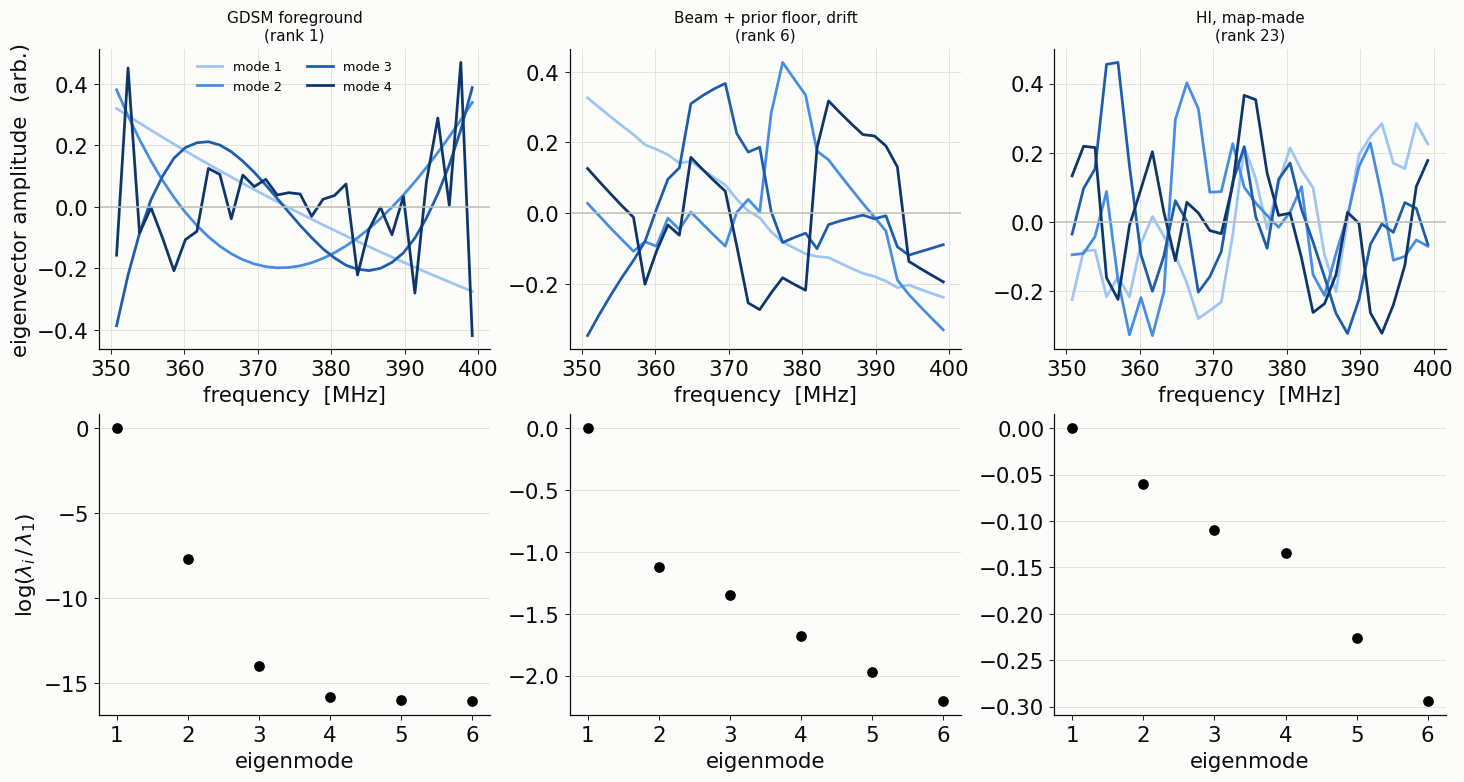

In [15]:
# ==== hi_eigenvectors ===============================================
rank = RK
nmodes = 4   # eigenvectors drawn
nbars  = 6   # eigenvalues in the lower row
# ---- palette + style (edit freely; this cell owns all of it) --------------
DRIFT, RASTER, THIRD = "#2a78d6", "#eb6834", "#1baf7a"
SURFACE = "#fcfcfb"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"
DPI_OUT = 200

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.size": 14, "axes.labelsize": 14, "axes.titlesize": 10.5,
    "axes.edgecolor": INK, "axes.labelcolor": INK,
    "xtick.color": INK, "ytick.color": INK,
    "xtick.labelsize": 14, "ytick.labelsize": 14,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.fontsize": 14,
    "lines.linewidth": 2.0, "figure.dpi": 110,
})

def _tidy(ax):
    ax.set_axisbelow(True)
    ax.tick_params(length=3, width=0.6)
    return ax

from matplotlib.colors import LinearSegmentedColormap
ramp = LinearSegmentedColormap.from_list(
    "blues", ["#9ec5f4", "#5598e7", "#2a78d6", "#184f95", "#0d366b"])
freqs = rank["freqs"]
panels = [("drift_V_fg", "drift_w_fg", INK,
           "GDSM foreground\n(rank 1)"),
          ("drift_V_floor", "drift_w_floor", DRIFT,
           "Beam + prior floor, drift\n(rank 6)"),
          ("drift_V_hi", "drift_w_hi", THIRD,
           "HI, map-made\n(rank 23)")]
fig, axes = plt.subplots(2, 3, figsize=(13.2, 7.0),
                         sharex="row", layout="constrained")

for col, (vkey, wkey, colour, title) in enumerate(panels):
    # --- top: the shapes -------------------------------------------
    ax = _tidy(axes[0, col])
    V = rank[vkey]
    for m in range(min(nmodes, V.shape[1])):
        v = V[:, m]
        # Sign of an eigenvector is arbitrary; fix it so the panels are
        # comparable rather than flipping at random between components.
        if v[np.argmax(np.abs(v))] < 0:
            v = -v
        ax.plot(freqs, v, color=ramp(m / max(nmodes - 1, 1)), lw=1.8,
                label=f"mode {m + 1}")
    ax.axhline(0.0, color=BASELINE, lw=1.0)
    ax.set_xlabel("frequency  [MHz]")
    ax.set_title(title, color=INK, pad=6, fontsize=10)

    # --- bottom: how much each shape carries -----------------------
    ax = _tidy(axes[1, col])
    w = rank[wkey][:nbars]
    #ax.bar(np.arange(1, len(w) + 1), w, color=colour, width=0.62,
    #       edgecolor=SURFACE, linewidth=1.4, zorder=3)
    # rank-1 foreground -> 15 of its 32 eigenvalues are numerically non-positive;
    # log10 would turn those into nan/-inf and drop the points silently.
    ax.scatter(np.arange(1, len(w) + 1), np.log10(np.maximum(w, 1e-18)),
               color='k', zorder=3)
    #ax.set_ylim(0, 1.12)
    ax.set_xticks(np.arange(1, len(w) + 1))
    ax.set_xlabel("eigenmode")
    ax.grid(axis="x", visible=False)
    # Spell out the invisible bars rather than leaving them a mystery.
    '''if w[1] < 1e-3:
        ax.annotate(f"modes 2$-${len(w)} total\n"
                    f"{w[1:].sum():.0e} of mode 1",
                    (2.6, 0.5), ha="left", va="center",
                    fontsize=8.6, color=INK2)
    else:
        for i, v in enumerate(w[1:], start=2):
            ax.annotate(f"{v:.2f}", (i, v), textcoords="offset points",
                        xytext=(0, 3), ha="center", fontsize=7.6,
                        color=INK2)'''
axes[0, 0].set_ylabel("eigenvector amplitude  (arb.)")
axes[0, 0].legend(loc="upper center", fontsize=8.4, ncols=2)
axes[1, 0].set_ylabel("log($\\lambda_i\\,/\\,\\lambda_1$)")

if DRAW_TITLES:
    fig.suptitle("What the components are actually made of",
                 color=INK, fontsize=13, fontweight="semibold",
                 x=0.01, ha="left", y=1.11)
    fig.text(0.01, 1.02,
             "Top: leading eigenvectors of the channel-channel covariance. The "
             "foreground's mode 1 is a single smooth power law; its modes 2$-$4 look "
             "like structure but are floating-point noise.\n"
             "Bottom: how much each mode carries, on a LINEAR axis — the "
             "foreground's modes 2+ are a blank column, not a short one. That is "
             "what rank 1 looks like.",
             color=INK2, fontsize=9.4, ha="left")
out = os.path.join(FIGDIR, "hi_eigenvectors." + FMT)
fig.savefig(out, bbox_inches="tight", dpi=DPI_OUT)
print(out)

display(Image(out)) if FMT == "png" else None

## `hi_1f_scan`

How bad would 1/f have to be before it reached the beam + prior floor?

**Top row — the knee** (where 1/f gain power crosses white). Only the filled
circle is measured, one per slope: scaling one realisation scales the whole
pipeline linearly (`solve` is affine and differences out; `pca_clean` is
scale-invariant), so `ratio ~ knee**(alpha/2)` exactly. Drawing markers at every
knee would imply measurements that were not made.

**Bottom row — the low-frequency cut-off**, which changes the correlation
*shape*, so nothing factors out and every point is an independent draw.


figures/hi_1f_scan.pdf


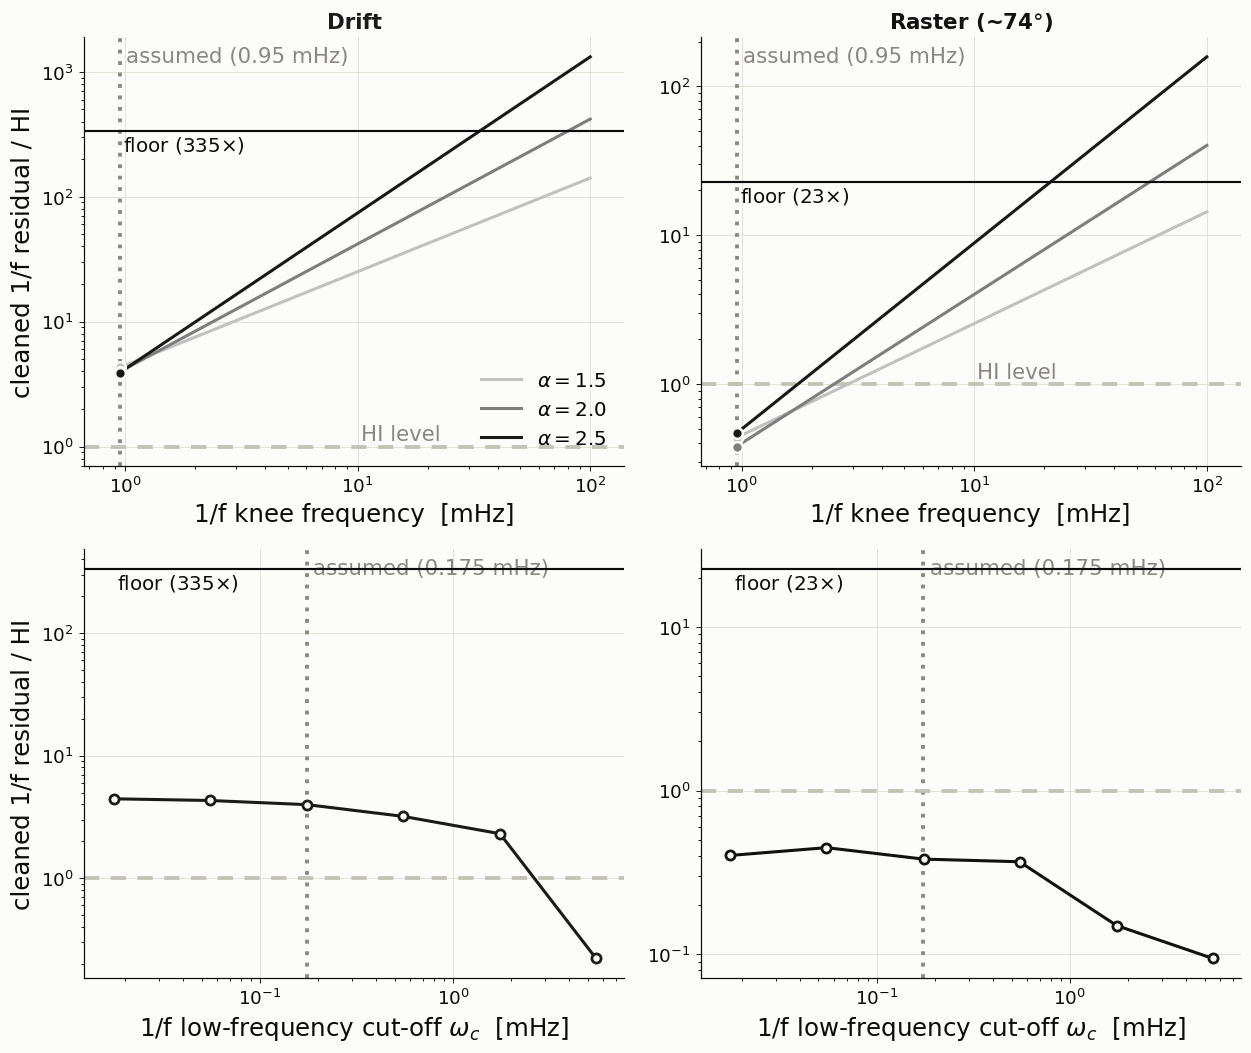

In [27]:
# ==== hi_1f_scan ====================================================
scan, cut, abl = SCAN, CUT, ABL
SHOW_CUTOFF = cut is not None
# ---- palette + style (edit freely; this cell owns all of it) --------------
DRIFT, RASTER, THIRD = "#1a1a1b", "#111111", "#1baf7a"
SURFACE = "#fcfcfb"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"
DPI_OUT = 200
# alpha is an ORDINAL family (a slope, not an identity), so one hue light to
# dark -- three categorical slots would imply three unrelated series.
RAMP = ["#c1c1c1", "#7e7e7e", "#181818"]

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.size": 14, "axes.labelsize": 16, "axes.titlesize": 14,
    "axes.edgecolor": INK, "axes.labelcolor": INK,
    "xtick.color": INK, "ytick.color": INK,
    "xtick.labelsize": 12, "ytick.labelsize": 12,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.fontsize": 13,
    "lines.linewidth": 2.0, "figure.dpi": 110,
})

STRAT = {"drift":  dict(color=DRIFT,  label="Drift"),
         "raster": dict(color=RASTER, label="Raster (~74$\\degree$)")}

def _tidy(ax):
    ax.set_axisbelow(True)
    ax.tick_params(length=3, width=0.6)
    return ax

def _floor(s, nm):
    """The thing 1/f is being compared against, from the ablation."""
    if abl is None:
        return None
    return float(np.median(np.sqrt(abl[f"{s}_cr_floor_{nm}"] / abl[f"{s}_cr_p_hi"])))

knees = np.asarray(scan["knees_mhz"], float)
alphas = [float(a) for a in scan["alphas"]]
nm = int(scan["nmodes"])
kfid = float(scan["fiducial_knee_mhz"])

nrow = 2 if SHOW_CUTOFF else 1
fig, axes = plt.subplots(nrow, 2, squeeze=False, figsize=(11.6, 4.9 * nrow))

# ---- top row: the knee ---------------------------------------------------
for ax, s in zip(axes[0], ("drift", "raster")):
    _tidy(ax)
    for a, colour in zip(alphas, RAMP):
        y = np.array([scan[f"{s}_ratio_a{a}_k{k}"] for k in knees], float)
        ax.plot(knees, y, color=colour, lw=2.0, zorder=3, label=f"$\\alpha = {a}$")
        j = int(np.argmin(np.abs(knees - kfid)))     # the measured anchor
        ax.plot([knees[j]], [y[j]], color=colour, marker="o", ms=7,
                mfc=colour, mec=SURFACE, mew=1.6, zorder=5)
    fl = _floor(s, nm)
    if fl is not None:
        ax.axhline(fl, color=INK, lw=1.4, zorder=4)
        ax.annotate(f"floor ({fl:.0f}$\\times$)", (knees[0], fl),
                    textcoords="offset points", xytext=(2, -13), color=INK,
                    fontsize=13)
    ax.axhline(1.0, color=BASELINE, lw=2.5, ls=(0, (4, 3)), zorder=2)
    ax.annotate("HI level", (knees[3], 1.0), textcoords="offset points",
                xytext=(2, 4), color=MUTED, fontsize=14)
    # An unlabelled reference line is unreadable once DRAW_TITLES is off, so
    # the fiducial is named in the panel rather than only in the subtitle.
    ax.axvline(kfid, color=MUTED, lw=2.5, ls=(0, (1, 2)), zorder=1)
    ax.annotate(f"assumed ({kfid:.2f} mHz)", (kfid, 1.0),
                xycoords=("data", "axes fraction"), textcoords="offset points",
                xytext=(4, -6), color=MUTED, fontsize=14,
                rotation=0, va="top", ha="left")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(knees.min() * 0.7, knees.max() * 1.4)
    ax.set_xlabel("1/f knee frequency  [mHz]")
    ax.set_title(STRAT[s]["label"], color=STRAT[s]["color"], pad=6,
                 fontweight="semibold")
axes[0, 0].set_ylabel(f"cleaned 1/f residual / HI")
axes[0, 0].legend(loc="best", fontsize=13)

# ---- bottom row: the cut-off --------------------------------------------
if SHOW_CUTOFF:
    wcs = np.asarray(cut["cutoffs_mhz"], float)
    wc_fid = float(cut["fiducial_wc_mhz"])
    for ax, s in zip(axes[1], ("drift", "raster")):
        _tidy(ax)
        y = [cut[f"{s}_ratio_wc{w}"] for w in wcs]
        ax.plot(wcs, y, color=STRAT[s]["color"], marker="o", ms=6,
                mfc=SURFACE, mew=1.8, zorder=3)
        fl = _floor(s, nm)
        if fl is not None:
            ax.axhline(fl, color=INK, lw=1.4, zorder=4)
            ax.annotate(f"floor ({fl:.0f}$\\times$)", (wcs[0], fl),
                        textcoords="offset points", xytext=(2, -13),
                        color=INK, fontsize=13)
        ax.axhline(1.0, color=BASELINE, lw=2.5, ls=(0, (4, 3)), zorder=2)
        ax.axvline(wc_fid, color=MUTED, lw=2.5, ls=(0, (1, 2)), zorder=1)
        ax.annotate(f"assumed ({wc_fid:.3f} mHz)", (wc_fid, 1.0),
                    xycoords=("data", "axes fraction"),
                    textcoords="offset points", xytext=(4, -6), color=MUTED,
                    fontsize=14, rotation=0, va="top", ha="left")
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlim(wcs.min() * 0.7, wcs.max() * 1.4)
        ax.set_xlabel("1/f low-frequency cut-off $\\omega_c$  [mHz]")
    axes[1, 0].set_ylabel("cleaned 1/f residual / HI")

if DRAW_TITLES:
    fig.suptitle("1/f would have to be orders of magnitude worse to matter",
                 color=INK, fontsize=13, fontweight="semibold",
                 x=0.045, ha="left", y=1.03)
    sub = ("Top: knee = where 1/f gain power crosses white. Filled circles are "
           "measured, one per slope; lines are the exact "
           "$\\propto\\,$knee$^{\\alpha/2}$ scaling.")
    if SHOW_CUTOFF:
        sub += ("\nBottom: the cut-off, every point an independent draw. Left of "
                "the assumed value the curve is flat while the gain rms grows "
                "2.6$\\times$ — power on timescales longer than a pass "
                "multiplies a rank-1 foreground, so the cleaning removes it too.")
    fig.text(0.045, 0.965, sub, color=INK2, fontsize=9.4, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.93 if DRAW_TITLES else 1.0))
out = os.path.join(FIGDIR, "hi_1f_scan." + FMT)
fig.savefig(out, bbox_inches="tight", dpi=DPI_OUT)
print(out)

display(Image(out)) if FMT == "png" else None


## `hi_modes`

How many independent sky modes each strategy measures — the eigenspectrum of the
map-maker's information matrix `A^T N^-1 A`, with the same noise weighting the
solves use. Everything below the cut is filled by the prior, which *is* the beam
+ prior floor. Counts at 350.8 MHz: drift 8 / 17 / 23 and raster 14 / 33 / 55
modes above 10% / 1% / 0.1% of the largest eigenvalue.


figures/hi_modes.pdf


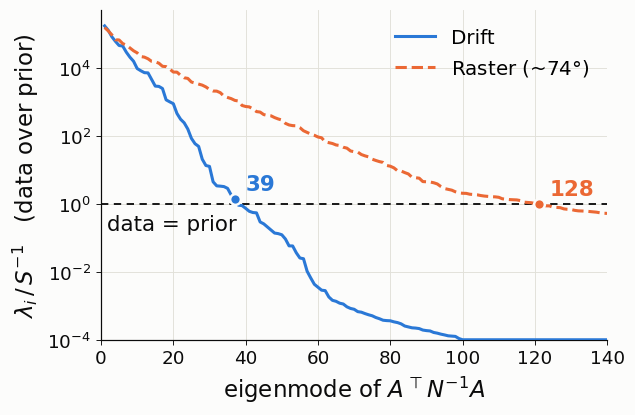

In [62]:
# ==== hi_modes ======================================================
modes = MODES
nshow = 140
# The count is tr(WA) = sum lam/(lam + S^-1): the degrees of freedom the DATA
# constrains, no threshold. A fixed fraction of lam_max was used before and is
# not defensible -- the drift-to-raster factor moves with where the line is
# drawn (1.75x at 10%, 1.94x at 1%, 2.39x at 0.1%) where tr(WA) gives 3.30x.
# Threshold counts are still in MODES as MODES['<strategy>_n0.01'] etc.
# ---- palette + style (edit freely; this cell owns all of it) --------------
DRIFT, RASTER, THIRD = "#2a78d6", "#eb6834", "#1baf7a"
SURFACE = "#fcfcfb"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"
DPI_OUT = 200
FLOOR = 1e-4                    # clamp for the log axis, see note below

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.size": 14, "axes.labelsize": 14, "axes.titlesize": 14,
    "axes.edgecolor": INK, "axes.labelcolor": INK,
    "xtick.color": INK, "ytick.color": INK,
    "xtick.labelsize": 12, "ytick.labelsize": 12,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2.0, "figure.dpi": 110,
})

STRAT = {"drift":  dict(color=DRIFT,  label="Drift", linestyle='-'),
         "raster": dict(color=RASTER, label="Raster (~74$\\degree$)", linestyle='--')}

def _tidy(ax):
    ax.set_axisbelow(True)
    ax.tick_params(length=3, width=0.6)
    return ax

fig, ax = plt.subplots(figsize=(6, 4))
_tidy(ax)
for s in ("drift", "raster"):
    w = np.asarray(modes[f"{s}_eig_abs"], float)
    s_inv = float(modes[f"{s}_s_inv"])          # the prior the solves use
    n_eff = float(modes[f"{s}_n_eff"])          # tr(WA)
    n_cross = int(modes[f"{s}_n_above_prior"])  # where lam crosses S^-1
    colour = STRAT[s]["color"]
    # NOTE: the drift's tail is CLAMPED at FLOOR -- those eigenvalues are
    # numerically zero, i.e. directions on the sky the scan never constrains.
    # The flat run near the bottom is the clamp, not a measured plateau.
    y = np.maximum(w[:nshow] / s_inv, FLOOR)
    ax.plot(np.arange(1, len(y) + 1), y, color=colour, lw=2.0, zorder=3,
            label=f"{STRAT[s]['label']}", linestyle=STRAT[s]['linestyle'])
    ax.plot([n_cross], [y[n_cross - 1]], color=colour, marker="o", ms=7,
            mfc=colour, mec=SURFACE, mew=1.6, zorder=5)
    ax.annotate(f"{n_eff:.0f}", (n_cross, y[n_cross - 1]),
                textcoords="offset points", xytext=(7, 6), color=colour,
                fontsize=14, fontweight="semibold")
ax.axhline(1.0, color=INK, lw=1.2, ls=(0, (4, 3)), zorder=2)
# Left edge: the raster crosses near the right, where this would sit on its count.
ax.annotate("data = prior", (0, 0.1), textcoords="offset points",
            xytext=(4, 5), ha="left", color=INK, fontsize=14)
ax.set_yscale("log")
ax.set_ylim(FLOOR, None)
ax.set_xlim(0, nshow)
ax.set_xlabel("eigenmode of $A^{\\top} N^{-1} A$", fontsize=15)
ax.set_ylabel("$\\lambda_i \\,/\\, S^{-1}$   (data over prior)", fontsize=15)
ax.legend(loc="upper right", fontsize=13)

if DRAW_TITLES:
    fig.suptitle("Cross-linking triples the sky the survey can measure",
                 color=INK, fontsize=13, fontweight="semibold",
                 x=0.02, ha="left", y=1.05)
    fig.text(0.02, 0.975,
             f"Information matrix at {float(modes['freq_mhz']):.0f} MHz, same "
             "noise weighting and prior as the solves. The count is tr($WA$), "
             "no threshold; everything below the line is prior rather than "
             "data, and that is the floor.",
             color=INK2, fontsize=9.4, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.90 if DRAW_TITLES else 1.0))
out = os.path.join(FIGDIR, "hi_modes." + FMT)
fig.savefig(out, bbox_inches="tight", dpi=DPI_OUT)
print(out)

display(Image(out)) if FMT == "png" else None
